# Sample 03: relative astrometry

This sample extends the pointing calibration in Sample 02 to a joint fit of the telescope pointing and every source position. A dense set of ordinary stars has one-arcsecond catalog uncertainties, while ten reference stars have one-milliarcsecond uncertainties. Their Gaussian catalog priors anchor the relative astrometric solution.

## 1. Imports and plotting configuration

Warpfield supplies the differentiable gnomonic observation model. Optax updates dimensionless pointing and source-coordinate corrections, and Equinox compiles the optimization step.

In [1]:
from astropy.coordinates import SkyCoord
from astropy.table import QTable
import astropy.units as u
import equinox as eqx
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

from warpfield import Astrometry, Exposure, Pointing, SourceCatalog
from warpfield.model import get_gnomonic

plt.rcParams['figure.dpi'] = 72
plt.rcParams['legend.frameon'] = False

## 2. Construct the true source field

The field consists of a $15 \times 15$ regular grid and ten randomly placed reference stars. All offsets are generated in a local sky-offset frame and then transformed to ICRS. The final ten entries are the reference stars.

In [2]:
seed = 42
rng = np.random.default_rng(seed)

true_ra = 100.0
true_dec = 20.0
true_pa = 12.0
n_reference = 10

grid = np.linspace(-0.45, 0.45, 15)
grid_x, grid_y = np.meshgrid(grid, grid)
reference_x = rng.uniform(-0.45, 0.45, n_reference)
reference_y = rng.uniform(-0.45, 0.45, n_reference)
offset_x = np.concatenate((grid_x.ravel(), reference_x))
offset_y = np.concatenate((grid_y.ravel(), reference_y))

center = SkyCoord(true_ra * u.deg, true_dec * u.deg, frame='icrs')
sky = SkyCoord(
  lon=offset_x * u.deg,
  lat=offset_y * u.deg,
  frame=center.skyoffset_frame(),
).icrs
true_source = SourceCatalog(sky.ra.degree, sky.dec.degree)
is_reference = np.arange(len(true_source)) >= len(true_source) - n_reference

print(f'{len(true_source)} sources ({is_reference.sum()} reference stars)')

235 sources (10 reference stars)


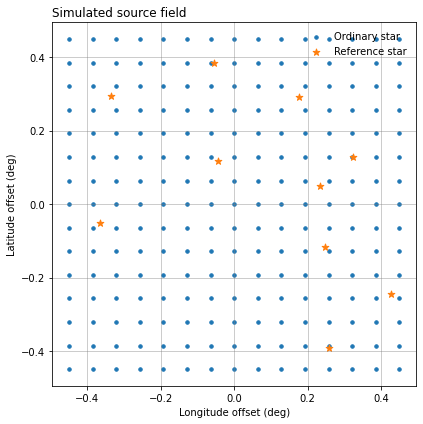

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
  offset_x[~is_reference], offset_y[~is_reference], s=12, label='Ordinary star'
)
ax.scatter(
  offset_x[is_reference],
  offset_y[is_reference],
  s=50,
  marker='*',
  label='Reference star',
)
ax.set_aspect(1.0, adjustable='box')
ax.grid(True, color='gray', alpha=0.5)
ax.set_xlabel('Longitude offset (deg)')
ax.set_ylabel('Latitude offset (deg)')
ax.set_title('Simulated source field', loc='left')
ax.legend()
fig.tight_layout()
plt.show()

## 3. Generate detector measurements

`get_gnomonic(simulator=True)` provides a distortion-free telescope with a one-arcsecond pixel scale. We observe the true catalog at the true pointing and add independent Gaussian errors of 0.01 pixel, equivalent to 10 mas at this plate scale.

In [4]:
telescope = get_gnomonic(simulator=True)
true_pointing = Pointing([true_ra], [true_dec], [true_pa])
measurement = telescope.observe(
  true_source,
  Exposure(true_pointing),
  error=0.01,
  seed=seed,
)

print(f'{len(measurement)} measurements')
print(
  'Measurement uncertainty:', float(measurement.uncertainty[0, 0]), 'pixel'
)

235 measurements
Measurement uncertainty: 0.01 pixel


## 4. Sample the input catalog and define its priors

Ordinary stars are known to 1 arcsec in each coordinate; reference stars are known to 1 mas. We independently sample right ascension and declination from those uncertainties and store the same standard deviations in `SourceCatalog.ra_error` and `SourceCatalog.dec_error`.

This example treats the two coordinate errors as independent Gaussian variables. It does not include an RA–Dec covariance.

In [5]:
ordinary_error = (1.0 * u.arcsec).to_value(u.deg)
reference_error = (1.0 * u.mas).to_value(u.deg)
source_error = np.where(is_reference, reference_error, ordinary_error)

initial_source = SourceCatalog(
  np.asarray(true_source.ra) + rng.normal(scale=source_error),
  np.asarray(true_source.dec) + rng.normal(scale=source_error),
  ra_error=source_error,
  dec_error=source_error,
)
initial_pointing = Pointing(
  [true_ra + 10.0 / 3600],
  [true_dec - 8.0 / 3600],
  [true_pa + 0.2],
)
initial = Astrometry(
  initial_source,
  telescope,
  Exposure(initial_pointing),
)

print('Ordinary-star uncertainty:', ordinary_error * 3.6e6, 'mas')
print('Reference-star uncertainty:', reference_error * 3.6e6, 'mas')

Ordinary-star uncertainty: 1000.0 mas
Reference-star uncertainty: 1.0000000000000002 mas


## 5. Define the posterior objective

The optimized variables are normalized offsets from the initial values. Source-coordinate offsets are expressed in units of their individual catalog uncertainties: a unit offset therefore means 1 arcsec for an ordinary star but only 1 mas for a reference star. Pointing offsets use the explicitly defined `pointing_scale`. This normalization gives the differently scaled quantities comparable numerical magnitudes.

The objective is the negative log posterior up to an additive constant: a measurement term weighted by the 0.01-pixel uncertainty plus independent standard-normal priors on the source-coordinate corrections. The pointing has no explicit prior.

In [6]:
source_scale = jnp.asarray(source_error)
pointing_scale = jnp.asarray([1.0 / 3600, 1.0 / 3600, 0.1])

normalized_offsets = {
  'pointing': jnp.zeros(3),
  'source_ra': jnp.zeros(len(initial_source)),
  'source_dec': jnp.zeros(len(initial_source)),
}


def build_astrometry(normalized_offsets):
  pointing_offset = normalized_offsets['pointing'] * pointing_scale
  pointing = Pointing(
    initial_pointing.ra + pointing_offset[0],
    initial_pointing.dec + pointing_offset[1],
    initial_pointing.position_angle + pointing_offset[2],
  )
  source = SourceCatalog(
    initial_source.ra + normalized_offsets['source_ra'] * source_scale,
    initial_source.dec + normalized_offsets['source_dec'] * source_scale,
    ra_error=initial_source.ra_error,
    dec_error=initial_source.dec_error,
  )
  return Astrometry(source, telescope, Exposure(pointing))


def negative_log_posterior(normalized_offsets):
  current = build_astrometry(normalized_offsets)
  residual = current.residual(measurement) / measurement.uncertainty
  measurement_term = 0.5 * jnp.sum(residual**2)
  prior_term = 0.5 * (
    jnp.sum(normalized_offsets['source_ra'] ** 2)
    + jnp.sum(normalized_offsets['source_dec'] ** 2)
  )
  return measurement_term + prior_term

## 6. Optimize with Optax

L-BFGS jointly updates the three pointing parameters and all source right ascensions and declinations. Only the standardized correction arrays are optimized; the telescope model and catalog uncertainties remain fixed. Optax's line search is useful for this tightly coupled but smooth posterior.

In [7]:
optimizer = optax.lbfgs()
optimizer_state = optimizer.init(normalized_offsets)
value_and_grad = optax.value_and_grad_from_state(negative_log_posterior)


@eqx.filter_jit
def step(normalized_offsets, optimizer_state):
  loss, gradient = value_and_grad(normalized_offsets, state=optimizer_state)
  updates, optimizer_state = optimizer.update(
    gradient,
    optimizer_state,
    normalized_offsets,
    value=loss,
    grad=gradient,
    value_fn=negative_log_posterior,
  )
  normalized_offsets = optax.apply_updates(normalized_offsets, updates)
  return normalized_offsets, optimizer_state, loss


losses = []
for iteration in range(100):
  normalized_offsets, optimizer_state, loss = step(
    normalized_offsets, optimizer_state
  )
  losses.append(float(loss))

fitted = build_astrometry(normalized_offsets)

## 7. Inspect the solution

The reference-star priors establish the absolute origin and orientation, while the detector measurements refine the much less certain ordinary-star positions relative to that frame.

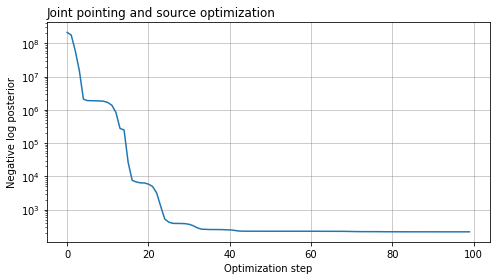

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(losses)
ax.grid(True, color='gray', alpha=0.5)
ax.set_xlabel('Optimization step')
ax.set_ylabel('Negative log posterior')
ax.set_title('Joint pointing and source optimization', loc='left')
fig.tight_layout()
plt.show()

In [9]:
fitted_pointing = fitted.exposure.pointing
pointing_result = QTable({
  'parameter': ['ra', 'dec', 'position_angle'],
  'truth': [true_ra, true_dec, true_pa] * u.deg,
  'initial': [
    float(initial_pointing.ra[0]),
    float(initial_pointing.dec[0]),
    float(initial_pointing.position_angle[0]),
  ]
  * u.deg,
  'fitted': [
    float(fitted_pointing.ra[0]),
    float(fitted_pointing.dec[0]),
    float(fitted_pointing.position_angle[0]),
  ]
  * u.deg,
})
pointing_result

parameter,truth,initial,fitted
,deg,deg,deg
str14,float64,float64,float64
ra,100.0,100.00277777777778,100.00000101346536
dec,20.0,19.997777777777777,20.000000193841196
position_angle,12.0,12.2,11.99989288250426


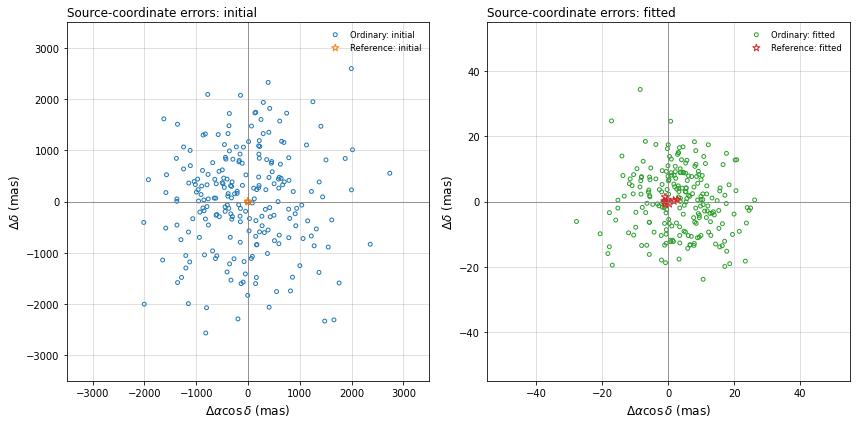

In [10]:
cos_dec = np.cos(np.deg2rad(np.asarray(true_source.dec)))
initial_ra_error = (
  (np.asarray(initial_source.ra) - np.asarray(true_source.ra))
  * cos_dec
  * 3.6e6
)
initial_dec_error = (
  np.asarray(initial_source.dec) - np.asarray(true_source.dec)
) * 3.6e6
fitted_ra_error = (
  (np.asarray(fitted.source.ra) - np.asarray(true_source.ra)) * cos_dec * 3.6e6
)
fitted_dec_error = (
  np.asarray(fitted.source.dec) - np.asarray(true_source.dec)
) * 3.6e6

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
ax = axes[0]
ax.scatter(
  initial_ra_error[~is_reference],
  initial_dec_error[~is_reference],
  s=15,
  facecolors='none',
  edgecolors='C0',
  label='Ordinary: initial',
)
ax.scatter(
  initial_ra_error[is_reference],
  initial_dec_error[is_reference],
  s=55,
  marker='*',
  facecolors='none',
  edgecolors='C1',
  label='Reference: initial',
)
ax.set_xlim(-3500, 3500)
ax.set_ylim(-3500, 3500)
ax.set_title('Source-coordinate errors: initial', loc='left')

ax = axes[1]
ax.scatter(
  fitted_ra_error[~is_reference],
  fitted_dec_error[~is_reference],
  s=15,
  facecolors='none',
  edgecolors='C2',
  label='Ordinary: fitted',
)
ax.scatter(
  fitted_ra_error[is_reference],
  fitted_dec_error[is_reference],
  s=55,
  marker='*',
  facecolors='none',
  edgecolors='C3',
  label='Reference: fitted',
)
ax.set_xlim(-55, 55)
ax.set_ylim(-55, 55)
ax.set_title('Source-coordinate errors: fitted', loc='left')

for ax in axes:
  ax.axhline(0, color='gray', lw=0.8)
  ax.axvline(0, color='gray', lw=0.8)
  ax.grid(True, color='gray', alpha=0.3)
  ax.set_xlabel(r'$\Delta\alpha\cos\delta$ (mas)', fontsize=12)
  ax.set_ylabel(r'$\Delta\delta$ (mas)', fontsize=12)
  ax.legend(fontsize='small')
fig.tight_layout()
plt.show()

In [11]:
initial_residual = np.asarray(initial.residual(measurement))
final_residual = np.asarray(fitted.residual(measurement))
ordinary_position_error = np.r_[
  fitted_ra_error[~is_reference],
  fitted_dec_error[~is_reference],
]
reference_position_error = np.r_[
  fitted_ra_error[is_reference],
  fitted_dec_error[is_reference],
]

print(
  'Initial detector residual RMS:',
  f'{np.sqrt(np.mean(initial_residual**2)):.4f} pixel',
)
print(
  'Final detector residual RMS:  ',
  f'{np.sqrt(np.mean(final_residual**2)):.4f} pixel',
)
print(
  'Ordinary-star position RMS:   ',
  f'{np.sqrt(np.mean(ordinary_position_error**2)):.2f} mas',
)
print(
  'Reference-star position RMS:  ',
  f'{np.sqrt(np.mean(reference_position_error**2)):.2f} mas',
)

Initial detector residual RMS: 9.5203 pixel
Final detector residual RMS:   0.0023 pixel
Ordinary-star position RMS:    10.01 mas
Reference-star position RMS:   1.06 mas


## Summary

- The gnomonic simulator generates detector measurements with 0.01-pixel Gaussian errors.
- `SourceCatalog` carries independent coordinate uncertainties for ordinary and reference stars.
- Dimensionless source corrections express the Gaussian priors directly as standard-normal penalties.
- Optax jointly fits telescope pointing and all source coordinates.
- The high-precision reference stars anchor the relative solution while detector measurements refine the ordinary-star positions.